# GSE202642 HCC tumors: PGAM5-associated macrophage candidates

Seven HCC tumor samples (GSM6127499-GSM6127505) are analyzed. Four adjacent liver samples are excluded from differential expression. GEO sample order is not merged-library order. The merged barcode suffixes were independently resolved with original 10x R1 barcode evidence: two 1000-spot batches per sample, spots 1-1000 and 100001-101000, using a run containing original R1. The 16bp cell barcode from the 28bp technical read was matched against all eleven suffix-specific sets. Each batch has >=100 matches to the selected suffix and >=10x the next highest match count. Both batches agree, and all 11 samples have unique suffixes. Tumors are suffixes 5-11, adjacent liver 1-4. Evidence counts, SRA accessions and the resolver script are supplied. This is empirical mapping, not an author-supplied mapping file.

## Methods

Supplied human ENSG matrix: 36,601 features and 115,732 cells. QC requires >=500 detected genes and <20% mitochondrial counts (13 MT-* rows). GEO lists Assembly:mm10, inconsistent with actual human features; source data use human IDs here. Published aggregate cell counts differ from supplied matrix, so supplied counts determine denominators.

Author cell annotations are not supplied. All eleven QC libraries are clustered for exploratory identity annotation: total-count normalization to 10,000, log1p, 2000 Seurat HVGs excluding PGAM5, 30PCs, 15 neighbors, igraph Leiden1, seed0. C1Q-rich macrophage cluster criteria: C1QA/B/C each >=75% detection, CSF1R>=60%, TYROBP>=90%, CD1C<40%, FCN1<50%. DE includes only tumor cells from the selected clusters. These are inferred labels with incomplete C1Q-low subtype coverage. Marker thresholds were selected after target-agnostic review; no PGAM5 feature is used to cluster.

PGAM5 raw count >0 defines RNA detection; zero means nondetection, not protein negativity. Pool selected tumor macrophages, normalize to 10,000, log1p, Wilcoxon with tie correction, BH across all 36,601 features. No patient pairing, depth matching, or patient/sample/depth covariates. Filter FDR<0.05, |Scanpy approximate log2FC|>=1, >=10% detection in either group. Fold change uses back-transformed mean log expression, not arithmetic normalized mean. Defining PGAM5 is kept in full and passing tables but excluded from candidate up/down lists; mitochondrial/ribosomal candidates are retained.

ALB background is marked in several clusters; ambient RNA, phagocytosed RNA and doublets remain unresolved. Associations are exploratory and not a validated signature. Cell-level FDR does not establish donor-level replication or causality.

Sources: [GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE202642), [source article](https://doi.org/10.1038/s41421-023-00529-z), GEO family SOFT and NCBI SRA metadata/read endpoints. Input hashes and software versions are supplied.


In [1]:
from pathlib import Path
import json,numpy as np,pandas as pd,anndata as ad
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from IPython.display import display
R=Path.cwd();s=json.loads((R/'analysis_summary.json').read_text())
a=ad.read_h5ad(R/'macrophage_counts_QC.h5ad')
r=pd.read_csv(R/'GSE202642_HCC_tumor_PGAM5_full_DE.csv',index_col=0)
u=pd.read_csv(R/'GSE202642_HCC_tumor_PGAM5_upregulated.csv',index_col=0)
d=pd.read_csv(R/'GSE202642_HCC_tumor_PGAM5_downregulated.csv',index_col=0)
mapping=pd.read_csv(R/'sample_mapping_verified.csv',dtype={'library_suffix':str})
import gzip,collections
barcode_sets=collections.defaultdict(set)
for line in gzip.open(R/'GSE202642_barcodes.tsv.gz','rt'):
 barcode,suffix=line.strip().rsplit('-',1);barcode_sets[suffix].add(barcode)
evidence=pd.read_csv(R/'sample_mapping_read_barcode_evidence.csv.gz')
assert len(evidence)==22000 and not evidence.duplicated(['SRR','spot_id']).any()
for _,row in mapping.iterrows():
 for batch,stored in zip([1,100001],json.loads(row.evidence_counts_json)):
  ev=evidence[(evidence.GSM==row.GSM)&(evidence.batch_start==batch)]
  assert len(ev)==1000
  counts={suffix:int(ev.raw_16bp_cell_barcode.isin(bars).sum()) for suffix,bars in barcode_sets.items()}
  assert counts==stored
expected=set(mapping.loc[mapping.tissue.eq('HCC_tumor'),'sample_name'])
assert set(a.obs.Sample)==expected and a.obs.tissue.eq('HCC_tumor').all()
assert set(a.obs.library_suffix.astype(str))<=set(map(str,range(5,12)))
assert set(mapping.library_suffix)==set(map(str,range(1,12))) and mapping.GSM.is_unique
for counts,chosen in zip(mapping.evidence_counts_json,mapping.library_suffix):
 for c in json.loads(counts):
  assert max(c,key=c.get)==chosen and c[chosen]>=100
  assert c[chosen]>=10*max(max(v for k,v in c.items() if k!=chosen),1)
assert a.obs.n_genes.ge(500).all() and a.obs.pct_mt.lt(20).all()
assert a.obs_names.is_unique and a.var_names.is_unique
q=pd.read_csv(R/'cluster_annotation_decisions.csv',dtype={'cluster':str})
assert set(a.obs.leiden.astype(str))==set(q.loc[q.included_as_macrophage,'cluster'])
pg=np.flatnonzero(a.var.gene.eq('PGAM5'));assert len(pg)==1
pos=a.X[:,pg[0]].toarray().ravel()>0
assert np.array_equal(pos,a.obs.PGAM5_detected)
assert int(pos.sum())==s['PGAM5_positive_cells'] and int((~pos).sum())==s['PGAM5_undetected_cells']
assert len(a)==s['QC_inferred_macrophages']
assert np.allclose(multipletests(r.p_value,method='fdr_bh')[1],r.FDR,atol=1e-12)
eligible=r.FDR.lt(.05)&r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')
assert set(u.index)==set(r.index[eligible&r.log2FC.ge(1)])
assert set(d.index)==set(r.index[eligible&r.log2FC.le(-1)])
checks=[];totals=np.asarray(a.X.sum(axis=1)).ravel()
for i in u.index[:10]:
 raw=a.X[:,a.var_names.get_loc(i)].toarray().ravel();v=np.log1p(raw/totals*1e4)
 pv=mannwhitneyu(v[pos],v[~pos],method='asymptotic',alternative='two-sided',use_continuity=False).pvalue
 fc=np.log2((np.expm1(v[pos].mean())+1e-9)/(np.expm1(v[~pos].mean())+1e-9))
 assert np.isclose(pv,r.loc[i,'p_value'],rtol=.002,atol=1e-12)
 assert np.isclose(fc,r.loc[i,'log2FC'],atol=.002)
 assert np.isclose((raw[pos]>0).mean(),r.loc[i,'fraction_PGAM5_positive'])
 checks.append({'gene':r.loc[i,'gene'],'SciPy_p':pv,'Scanpy_p':r.loc[i,'p_value'],'recomputed_log2FC':fc,'reported_log2FC':r.loc[i,'log2FC']})
pd.DataFrame(checks).to_csv(R/'independent_calculation_checks.csv',index=False)
print('Scope, QC, annotation membership, raw PGAM5 grouping, BH and full candidate memberships verified.')
display(pd.DataFrame(checks));display(pd.Series(s,name='value').to_frame())
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120,'savefig.bbox':'tight'})


Scope, QC, annotation membership, raw PGAM5 grouping, BH and full candidate memberships verified.


,gene,SciPy_p,Scanpy_p,recomputed_log2FC,reported_log2FC
0,LMNB1,1.772483e-30,1.772483e-30,1.120590,1.120590
1,TCF19,1.372411e-29,1.372411e-29,1.301492,1.301492
2,PCLAF,3.022778e-29,3.022778e-29,1.328168,1.328168
3,MKI67,9.212195e-29,9.212195e-29,1.359223,1.359223
4,IGHG4,4.051614e-28,4.051614e-28,1.298955,1.298955
5,ANLN,1.161787e-27,1.161787e-27,1.462241,1.462241
6,WEE1,9.944473e-27,9.944473e-27,1.096958,1.096958
7,TK1,1.320716e-26,1.320716e-26,1.424043,1.424043
8,BIRC5,1.517921e-26,1.517921e-26,1.367470,1.367469
9,CENPK,3.906345e-26,3.906345e-26,1.232175,1.232175


,value
HCC_tumor_samples,7
source_tumor_cells,78435
QC_tumor_cells,56719
QC_inferred_macrophages,12907
PGAM5_positive_cells,919
PGAM5_undetected_cells,11988
samples_with_macrophages,7
samples_with_positive_macrophages,7
tested_genes,36601
macrophage_clusters,"[8, 9, 10, 23, 26]"


## Annotation audit

Macrophages are inferred from concordant C1Q, CSF1R and TYROBP expression rather than PGAM5. The chart also shows excluded CD1C/FCER1A-rich cluster22 and mixed hepatic/T-cell clusters19,20,21. These labels are exploratory and do not establish complete macrophage subtype coverage.


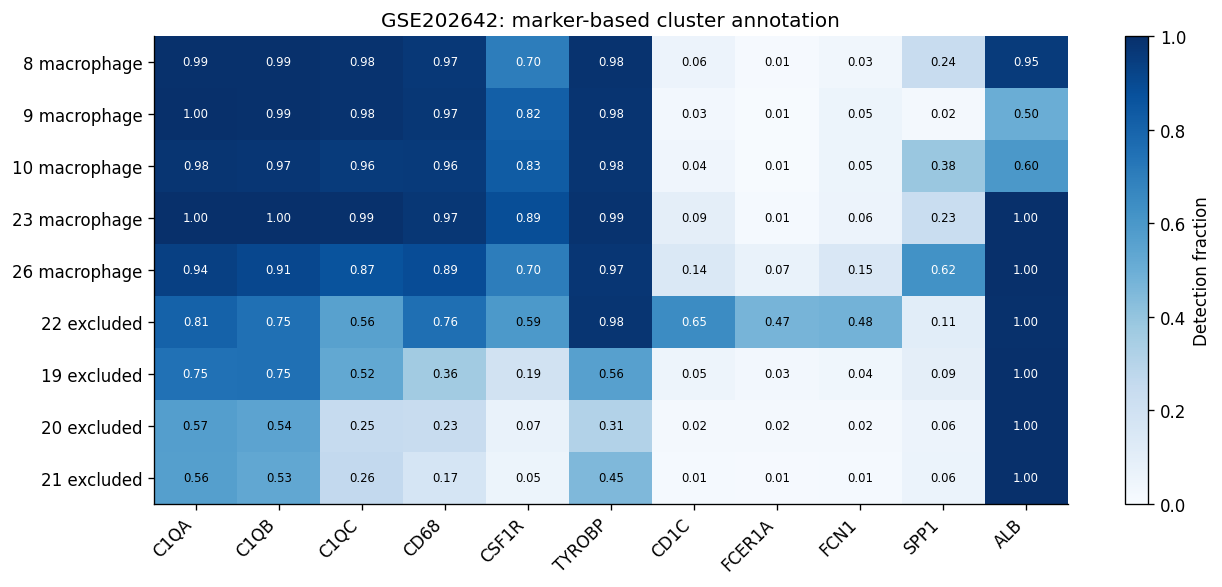

,cluster,cells,fraction_C1QA,fraction_C1QB,fraction_C1QC,fraction_CD68,fraction_CSF1R
8,8,1303,0.993093,0.994628,0.984651,0.966999,0.699923
9,9,528,0.998106,0.994318,0.984848,0.971591,0.818182
10,10,6509,0.977416,0.972961,0.956675,0.959134,0.829006
23,23,2323,0.997848,0.996987,0.994834,0.972449,0.885923
26,26,2835,0.936861,0.909700,0.867019,0.889947,0.700176


In [2]:
q=pd.read_csv(R/'cluster_annotation_decisions.csv',dtype={'cluster':str})
cl=s['macrophage_clusters']+['22','19','20','21']
genes=['C1QA','C1QB','C1QC','CD68','CSF1R','TYROBP','CD1C','FCER1A','FCN1','SPP1','ALB']
t=q.set_index('cluster').loc[cl,['fraction_'+g for g in genes]]
fig,ax=plt.subplots(figsize=(11,5));im=ax.imshow(t.to_numpy(),vmin=0,vmax=1,cmap='Blues',aspect='auto')
ax.set_xticks(range(len(genes)),genes,rotation=45,ha='right')
ax.set_yticks(range(len(cl)),[i+(' macrophage' if i in s['macrophage_clusters'] else ' excluded') for i in cl])
for i in range(len(cl)):
 for j in range(len(genes)):
  z=t.iloc[i,j];ax.text(j,i,f'{z:.2f}',ha='center',va='center',fontsize=7,color='white' if z>.6 else 'black')
ax.set_title('GSE202642: marker-based cluster annotation');fig.colorbar(im,ax=ax,label='Detection fraction')
fig.tight_layout();fig.savefig(R/'cluster_annotation_QA.png');fig.savefig(R/'cluster_annotation_QA.pdf');plt.show()
display(q[q.included_as_macrophage][['cluster','cells']+['fraction_'+g for g in ['C1QA','C1QB','C1QC','CD68','CSF1R']]])


## PGAM5 detection support

All seven HCC tumor samples are eligible. Rates use inferred macrophages as the denominator. Samples may contribute unequal numbers of cells; no balancing is performed.


,Sample,macrophages,PGAM5_positive,rate
0,1a-0618,2826,172,0.060863
1,1a-0629,1391,47,0.033789
2,1a-0706,2833,175,0.061772
3,1a-0707,2438,203,0.083265
4,1a-0727,504,110,0.218254
5,1a-0831,624,47,0.075321
6,2a-0706,2291,165,0.072021


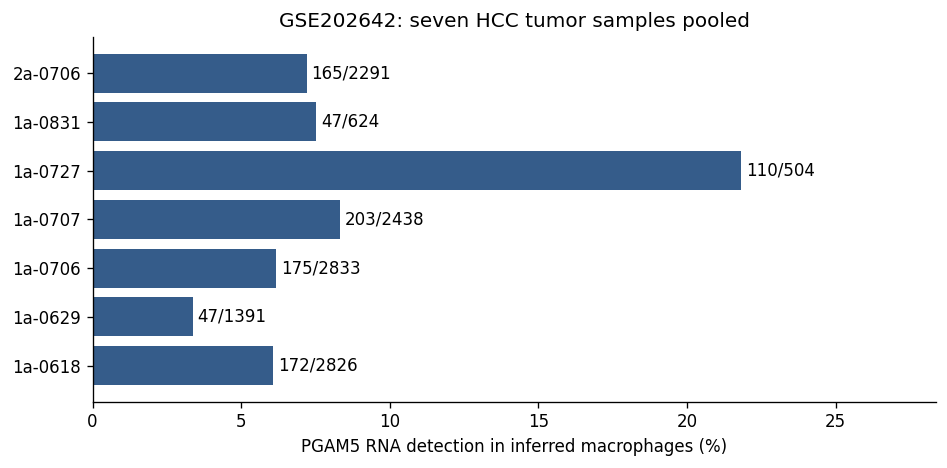

group,PGAM5_detected,PGAM5_undetected
gene,,
ALB,0.786,0.794
APOA1,0.509,0.521
C1QA,0.982,0.973
C1QB,0.978,0.964
C1QC,0.964,0.945
CD3D,0.038,0.027
CD68,0.973,0.945
CSF1R,0.887,0.791
EPCAM,0.011,0.006


In [3]:
t=pd.read_csv(R/'PGAM5_by_sample.csv');display(t)
fig,ax=plt.subplots(figsize=(8,4));ax.barh(t.Sample,t.rate*100,color='#355C8A')
for i,z in t.iterrows():ax.text(z.rate*100+.15,i,f'{z.PGAM5_positive}/{z.macrophages}',va='center')
ax.set_xlim(0,max(5,t.rate.max()*100*1.3));ax.set_xlabel('PGAM5 RNA detection in inferred macrophages (%)')
ax.set_title('GSE202642: seven HCC tumor samples pooled');fig.tight_layout()
fig.savefig(R/'PGAM5_detection_by_sample.png');fig.savefig(R/'PGAM5_detection_by_sample.pdf');plt.show()
display(pd.read_csv(R/'TAM_marker_QA.csv').pivot(index='gene',columns='group',values='fraction').round(3))


## Differential candidates

Volcano includes genes detected in >=10% of either group, excluding the defining PGAM5 gene. Orange/blue denote up/down candidates; gray denotes others. Gene candidates may reflect technical or patient/subtype differences and unresolved ambient RNA.


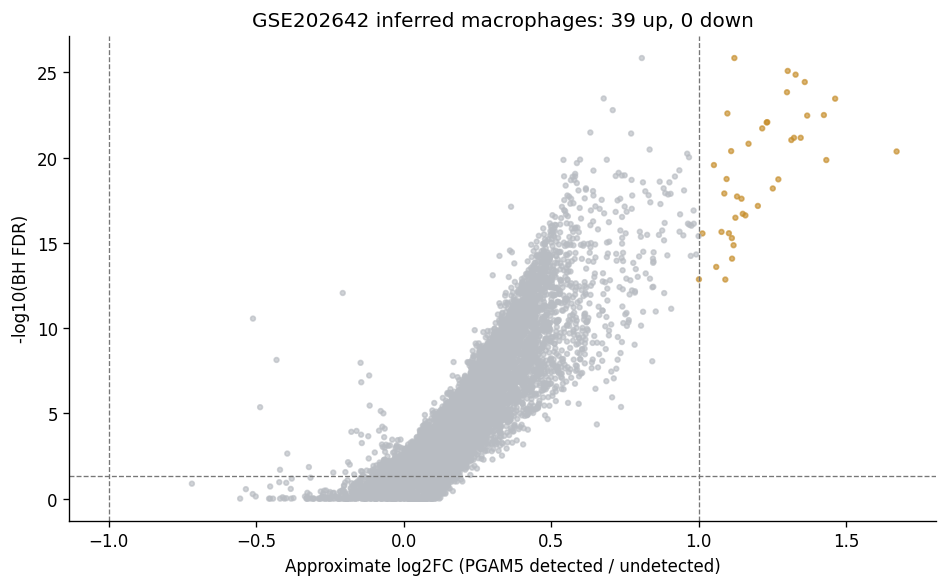

,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
names,,,,,
ENSG00000113368,LMNB1,1.120590,1.465930e-26,0.218716,0.095846
ENSG00000137310,TCF19,1.301492,8.371934e-26,0.128400,0.043210
ENSG00000166803,PCLAF,1.328168,1.382959e-25,0.162133,0.063063
ENSG00000148773,MKI67,1.359223,3.746395e-25,0.156692,0.060394
ENSG00000211892,IGHG4,1.298955,1.482931e-24,0.104461,0.032366
ENSG00000011426,ANLN,1.462241,3.543547e-24,0.112078,0.036620
ENSG00000166483,WEE1,1.096958,2.599840e-23,0.145811,0.055389
ENSG00000167900,TK1,1.424043,3.222636e-23,0.138194,0.052302
ENSG00000089685,BIRC5,1.367469,3.472339e-23,0.122960,0.043293


,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
names,,,,,


In [4]:
t=r[r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')]
color=np.where(t.FDR.lt(.05)&t.log2FC.ge(1),'#C68D29',np.where(t.FDR.lt(.05)&t.log2FC.le(-1),'#355C8A','#B8BCC2'))
fig,ax=plt.subplots(figsize=(8,5));ax.scatter(t.log2FC,-np.log10(t.FDR.clip(lower=1e-300)),s=8,c=color,alpha=.65)
ax.axhline(-np.log10(.05),ls='--',color='#777',lw=.8)
for x in [-1,1]:ax.axvline(x,ls='--',color='#777',lw=.8)
ax.set_xlabel('Approximate log2FC (PGAM5 detected / undetected)');ax.set_ylabel('-log10(BH FDR)')
ax.set_title(f'GSE202642 inferred macrophages: {len(u)} up, {len(d)} down')
fig.tight_layout();fig.savefig(R/'differential_expression.png');fig.savefig(R/'differential_expression.pdf');plt.show()
display(u[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']].head(20))
display(d[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']].head(20))


## Reproduction and limits

Download the four official GEO source files (matrix/features/barcodes/family SOFT). Install versions in environment_versions.txt. Run resolve_sample_mapping.py (uses small public SRA read requests, not full FASTQ downloads), prepare_all_libraries.py, analyze_PGAM5.py, build_notebook.py. The ZIP omits the large source, all-QC and macrophage count matrices; reproduce them using these scripts before rerunning notebook validation. PGAM5-associated genes may reflect subgroup/sample/technical differences and unresolved ambient RNA. No validated signature is claimed. Notebook executed in this environment; browser GUI rendering was not separately tested.
